In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import lagrange, CubicSpline
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline


def load_data(filepath):
    return pd.read_csv(filepath)

FILEPATH = 'building_materials_transactions.csv'
DATETIME_COL = 'date'
VALUE_COL = 'revenue'
CAT_COL = 'region'


def preprocess_data(df, datetime_col=None, value_col=None):
    if datetime_col and datetime_col in df.columns:
        df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
        df = df.sort_values(datetime_col).reset_index(drop=True)
    if value_col and value_col in df.columns:
        df = df.dropna(subset=[value_col]).reset_index(drop=True)
    return df


df = load_data(FILEPATH)

datetime_col = DATETIME_COL
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != datetime_col]
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(datetime_col)
print(numeric_cols)
print(categorical_cols)

value_col = "revenue"
cat_col = "region"

df = preprocess_data(df, datetime_col, value_col)

print('Форма данных:', df.shape)
print('Столбец времени:', datetime_col)
print('Числовой столбец:', value_col)
print('Категориальный столбец:', cat_col)
df.head()

date
['year', 'month', 'week_of_year', 'units', 'unit_price', 'revenue', 'housing_starts_index', 'lumber_price_index', 'mortgage_rate']
['date', 'region', 'product_category', 'sku', 'channel', 'customer_type']
Форма данных: (340000, 15)
Столбец времени: date
Числовой столбец: revenue
Категориальный столбец: region


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4592\3212798606.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


,date,year,month,week_of_year,region,product_category,sku,channel,customer_type,units,unit_price,revenue,housing_starts_index,lumber_price_index,mortgage_rate
0,2019-01-07,2019,1,2,East_North_Central,roofing,ROO-1877,pro_dealer,remodeler,3,85.01,255.03,96.4,388.0,3.95
1,2019-01-07,2019,1,2,West_North_Central,plumbing,PLU-6053,pro_dealer,homebuilder,4,26.36,105.44,96.4,388.0,3.95
2,2019-01-07,2019,1,2,West_North_Central,roofing,ROO-8329,pro_dealer,contractor,10,93.95,939.50,96.4,388.0,3.95
3,2019-01-07,2019,1,2,Mountain,roofing,ROO-3948,pro_dealer,homebuilder,34,87.00,2958.00,96.4,388.0,3.95
4,2019-01-07,2019,1,2,South_Atlantic,lumber,LUM-4143,big_box_diy,homebuilder,406,6.19,2513.14,96.4,388.0,3.95


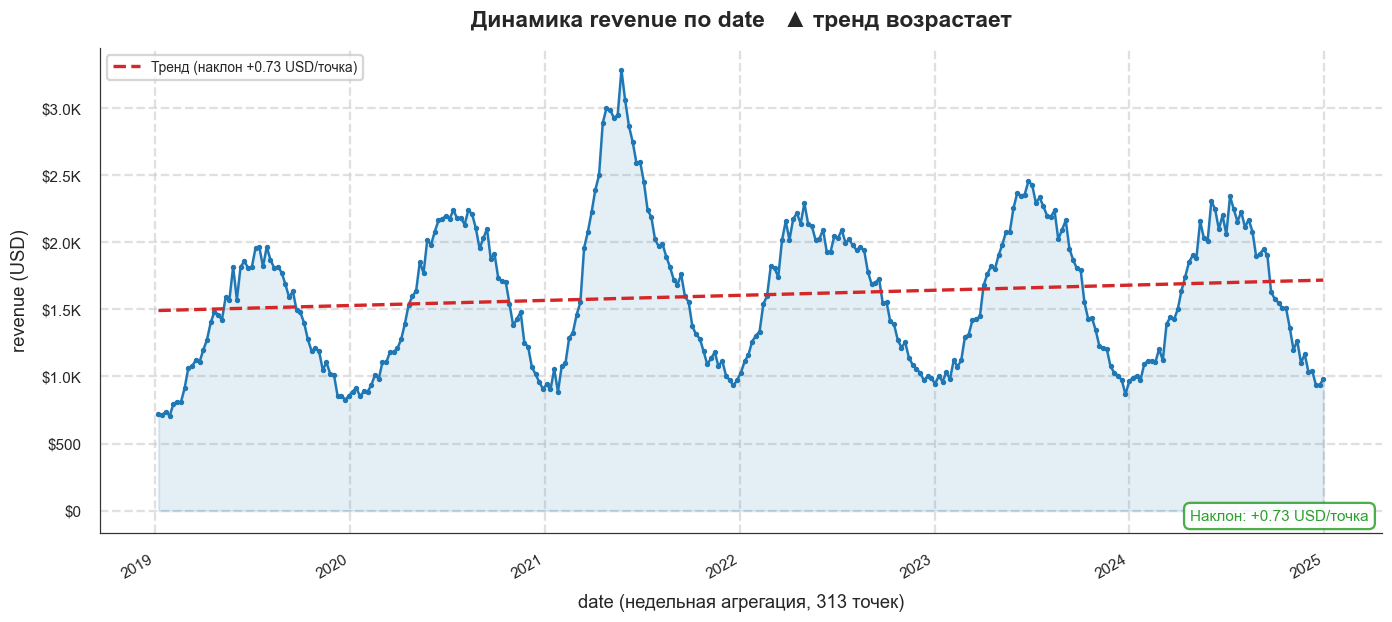

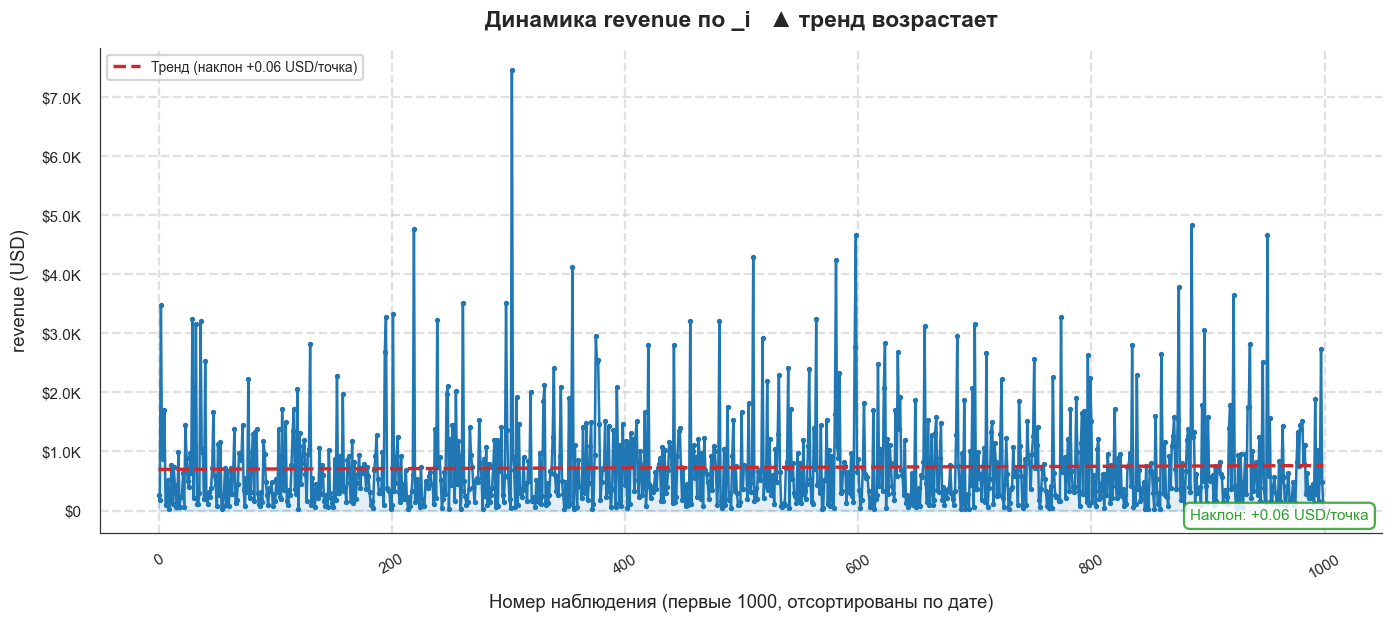

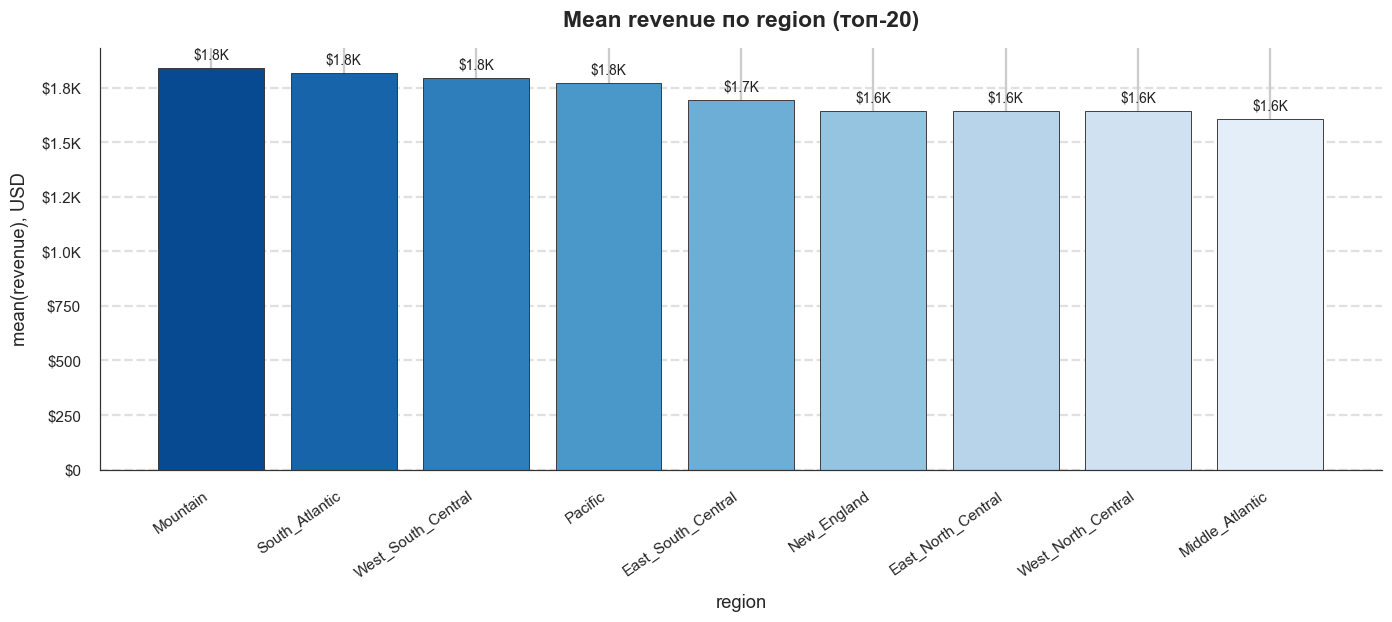

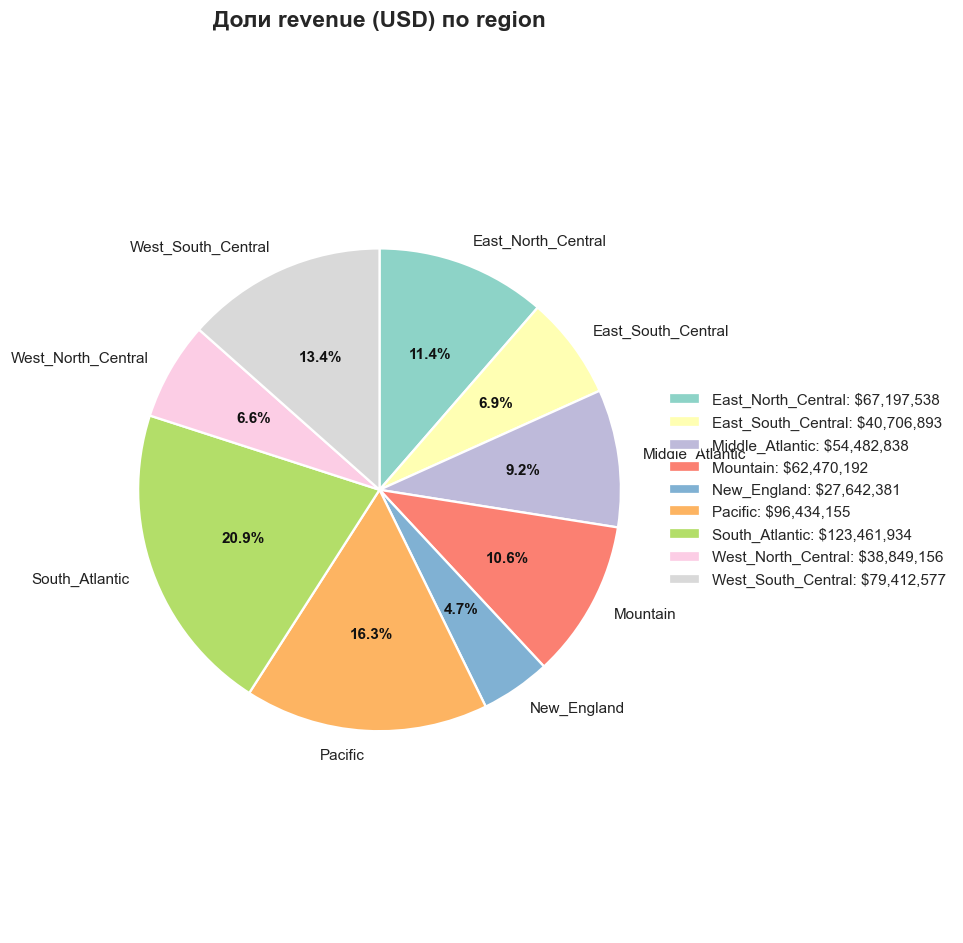

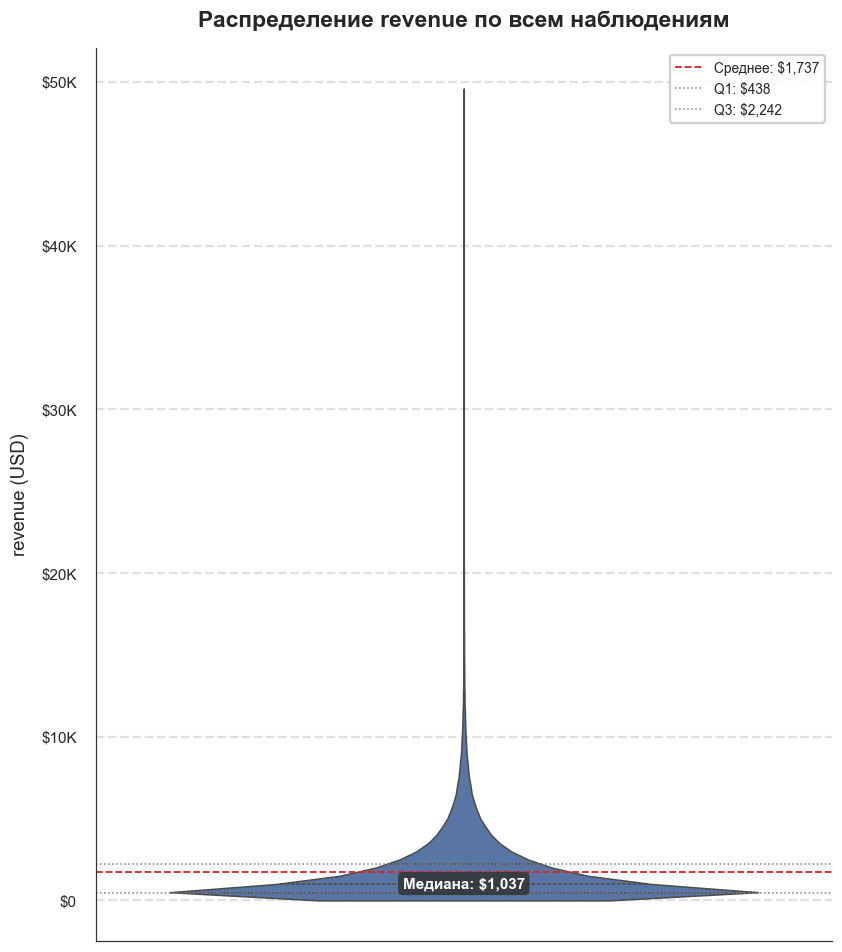

Описательные статистики (содержательные числовые признаки)
                         count         mean          std     min     25%  \
units                 340000.0   140.998726   233.354218    1.00   13.00   
unit_price            340000.0    51.284760    88.881355    5.43    8.35   
revenue               340000.0  1737.228427  2068.541393    5.80  438.30   
housing_starts_index  340000.0   107.818749     7.977620   92.70  100.80   
lumber_price_index    340000.0   497.285941   252.125178  333.00  392.00   
mortgage_rate         340000.0     5.518189     1.742805    2.84    3.88   

                          50%      75%       max  
units                   45.00   168.00   4301.00  
unit_price              14.05    42.24    503.91  
revenue               1037.40  2242.50  49596.74  
housing_starts_index   107.30   114.60    127.70  
lumber_price_index     408.00   430.00   1548.00  
mortgage_rate            5.52     7.42      7.63  

Матрица корреляций
                      units  un

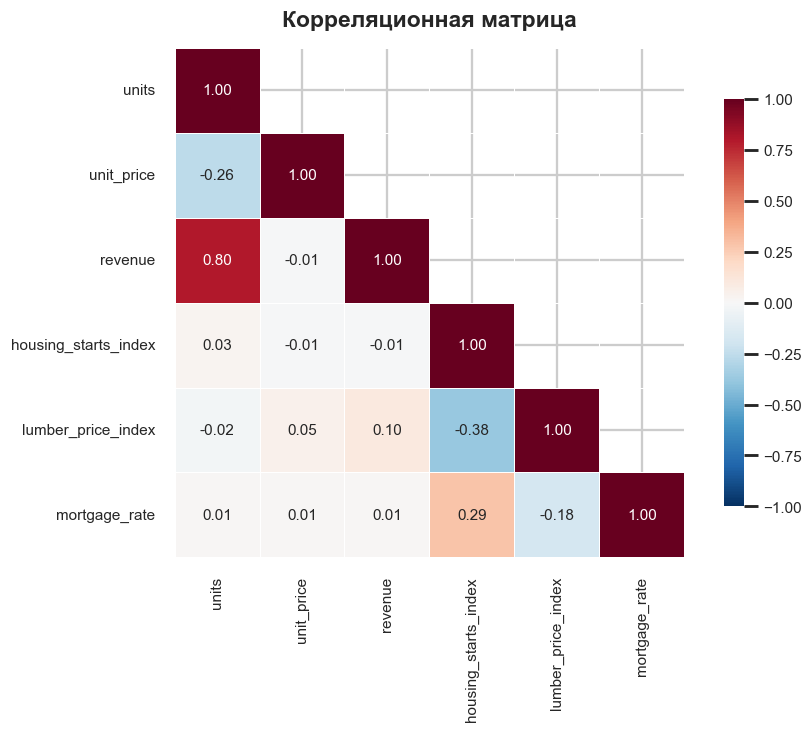


=== Агрегаты по категориям ===

--- revenue по region ---
                             sum       mean  count
region                                            
South_Atlantic      $123,461,934  $1,815.78  67994
Pacific              $96,434,155  $1,771.16  54447
West_South_Central   $79,412,577  $1,793.66  44274
East_North_Central   $67,197,538  $1,641.73  40931
Mountain             $62,470,192  $1,840.82  33936
Middle_Atlantic      $54,482,838  $1,607.26  33898
East_South_Central   $40,706,893  $1,694.99  24016
West_North_Central   $38,849,156  $1,640.87  23676
New_England          $27,642,381  $1,642.64  16828

--- revenue по product_category ---
                             sum       mean  count
product_category                                  
lumber              $218,761,038  $2,694.30  81194
concrete_cement      $95,642,512  $1,994.80  47946
roofing              $75,477,378  $2,021.68  37334
drywall              $58,574,698  $1,718.14  34092
insulation           $44,499,527  $1,

In [29]:
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8


def _dollar_formatter(x,_):
    if abs(x) >= 1_000_000:
        return f'${x/1_000_000:.1f}M'
    if abs(x) >= 10_000:
        return f'${x/1_000:.0f}K'
    if abs(x) >= 1_000:
        return f'${x/1_000:.1f}K'
    return f'${x:.0f}'


def _format_value_axis(ax):
    from matplotlib.ticker import FuncFormatter
    ax.yaxis.set_major_formatter(FuncFormatter(_dollar_formatter))


def plot_line(df, x_col, y_col, show_trend=True, x_label=None):
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(df[x_col], df[y_col].to_numpy(),
            color='#1f77b4', linewidth=1.6, marker='o', markersize=2.5)
    ax.fill_between(df[x_col], df[y_col].to_numpy(),
                    alpha=0.12, color='#1f77b4')

    ax.set_xlabel(x_label or x_col, labelpad=8)
    ax.set_ylabel(f'{y_col} (USD)', labelpad=8)

    if len(df) > 1:
        y = df[y_col].to_numpy(dtype=float)
        x = np.arange(len(y))
        coefs = np.polyfit(x, y, 1)
        slope = coefs[0]
        direction = 'возрастает' if slope > 0 else 'убывает'
        arrow = '▲' if slope > 0 else '▼'
        color = '#2ca02c' if slope > 0 else '#d62728'

        if show_trend:
            trend_line = np.polyval(coefs, x)
            ax.plot(df[x_col], trend_line,
                    color='#d62728', linewidth=2.2, linestyle='--',
                    label=f'Тренд (наклон {slope:+.2f} USD/точка)')
            ax.legend(loc='upper left', fontsize=9)

        ax.set_title(f'Динамика {y_col} по {x_col}   {arrow} тренд {direction}',
                     pad=14)
        ax.text(0.99, 0.02, f'Наклон: {slope:+.2f} USD/точка',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=10, color=color,
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='white', ec=color, alpha=0.85))
    else:
        ax.set_title(f'Динамика {y_col} по {x_col}', pad=14)

    _format_value_axis(ax)
    if pd.api.types.is_datetime64_any_dtype(df[x_col]):
        fig.autofmt_xdate(rotation=30, ha='right')
    else:
        ax.tick_params(axis='x', labelrotation=30)
    ax.grid(True, linestyle='--', alpha=0.6)
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()

def plot_bar(df, cat_col, value_col, agg='mean', top_n=20):
    grouped = (df.groupby(cat_col)[value_col].agg(agg)
                 .sort_values(ascending=False).head(top_n))

    fig, ax = plt.subplots(figsize=(13, 6))
    palette = sns.color_palette('Blues_r', n_colors=len(grouped))
    bars = ax.bar(grouped.index.astype(str), grouped.to_numpy(),
                  color=palette, edgecolor='#333333', linewidth=0.6)

    for bar in bars:
        h = bar.get_height()
        if abs(h) >= 1_000_000:
            label = f'${h/1_000_000:.2f}M'
        elif abs(h) >= 1_000:
            label = f'${h/1_000:.1f}K'
        else:
            label = f'${h:.2f}'
        ax.annotate(label, xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9, color='#222222')

    ax.set_xlabel(cat_col, labelpad=8)
    ax.set_ylabel(f'{agg}({value_col}), USD', labelpad=8)
    ax.set_title(f'{agg.capitalize()} {value_col} по {cat_col} (топ-{top_n})', pad=14)

    _format_value_axis(ax)
    plt.xticks(rotation=35, ha='right')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()


def plot_pie(df, cat_col, value_col=None, top_n=10):
    if value_col is not None:
        counts = df.groupby(cat_col)[value_col].sum()
        title = f'Доли {value_col} (USD) по {cat_col}'
        legend_prefix = '$'
    else:
        counts = df[cat_col].value_counts()
        title = f'Доли наблюдений по {cat_col}'
        legend_prefix = ''

    if len(counts) > top_n:
        head = counts.head(top_n)
        other = counts.iloc[top_n:].sum()
        counts = pd.concat([head, pd.Series({'Другие': other})])

    fig, ax = plt.subplots(figsize=(9, 9))
    palette = sns.color_palette('Set3', n_colors=len(counts))
    wedges, texts, autotexts = ax.pie(
        counts.to_numpy(),
        labels=counts.index.astype(str),
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        colors=palette,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops=dict(fontsize=10, color='#222222'),
    )
    for at in autotexts:
        at.set_color('#111111')
        at.set_fontweight('bold')
        at.set_fontsize(10)

    if value_col is not None:
        legend_labels = [f'{name}: ${value:,.0f}' for name, value in counts.items()]
        ax.legend(wedges, legend_labels, loc='center left',
                  bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=10)

    ax.set_title(title, pad=14)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()


def plot_violin(df, cat_col, value_col, top_n=10):
    values = df[value_col].dropna().to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8, 9))
    sns.violinplot(y=values, ax=ax, inner='quartile', cut=0,
                   color='#4c72b0', linewidth=1.0)

    median = np.median(values)
    mean = np.mean(values)
    q1, q3 = np.percentile(values, [25, 75])

    ax.text(0, median, f'Медиана: ${median:,.0f}',
            ha='center', va='center', fontsize=10, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='#333333', ec='none', alpha=0.85))
    ax.axhline(mean, color='#d62728', linestyle='--', linewidth=1.2,
               label=f'Среднее: ${mean:,.0f}')
    ax.axhline(q1, color='#7f7f7f', linestyle=':', linewidth=1.0,
               label=f'Q1: ${q1:,.0f}')
    ax.axhline(q3, color='#7f7f7f', linestyle=':', linewidth=1.0,
               label=f'Q3: ${q3:,.0f}')

    ax.set_ylabel(f'{value_col} (USD)', labelpad=8)
    ax.set_title(f'Распределение {value_col} по всем наблюдениям', pad=14)
    ax.set_xticks([])

    _format_value_axis(ax)
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()


def qualitative_analysis(df):
    exclude = {'year', 'month', 'week_of_year', 'date'}

    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df = numeric_df[[c for c in numeric_df.columns if c not in exclude]]

    if numeric_df.shape[1] == 0:
        print('Нет числовых столбцов для анализа.')
        return

    print('Описательные статистики (содержательные числовые признаки)')
    print(numeric_df.describe().T)

    if numeric_df.shape[1] > 1:
        print()
        print('Матрица корреляций')
        corr = numeric_df.corr()
        print(corr.round(3))

        fig, ax = plt.subplots(figsize=(9, 7))
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    square=True, linewidths=0.6, cbar_kws={'shrink': 0.8},
                    annot_kws={'size': 10}, ax=ax)
        ax.set_title('Корреляционная матрица', pad=14)
        plt.tight_layout()
        plt.show()

        print()
        print('=== Агрегаты по категориям ===')
        for cat in ('region', 'product_category', 'channel', 'customer_type'):
            if cat in df.columns:
                print(f'\n--- revenue по {cat} ---')
                agg = (df.groupby(cat)['revenue']
                         .agg(['sum', 'mean', 'count'])
                         .sort_values('sum', ascending=False))
                agg['sum'] = agg['sum'].map(lambda v: f'${v:,.0f}')
                agg['mean'] = agg['mean'].map(lambda v: f'${v:,.2f}')
                print(agg)
    else:
        print('Числовой столбец один — корреляции не строятся.')


if datetime_col and value_col:
    df_t = (df.groupby(datetime_col)[value_col].mean()
              .reset_index().sort_values(datetime_col).reset_index(drop=True))
    plot_line(df_t, datetime_col, value_col, True,
              x_label=f'{datetime_col} (недельная агрегация, {len(df_t)} точек)')

if value_col:
    df_1000 = (df.sort_values(datetime_col).reset_index(drop=True)
                 .head(1000).copy())
    df_1000['_i'] = df_1000.index
    plot_line(df_1000, '_i', value_col, True,
              x_label='Номер наблюдения (первые 1000, отсортированы по дате)')
if cat_col and value_col:
    plot_bar(df, cat_col, value_col)
    plot_pie(df, cat_col, value_col)
    plot_violin(df, cat_col, value_col)

qualitative_analysis(df)

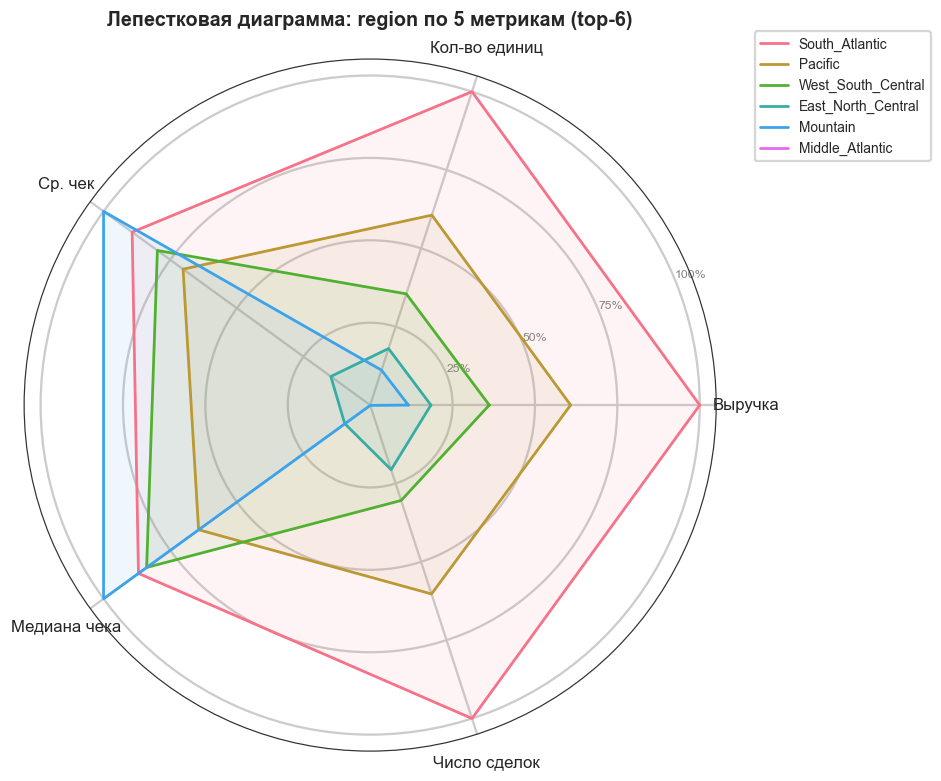


=== Исходные значения метрик по категориям ===
                         Выручка  Кол-во единиц  Ср. чек  Медиана чека  Число сделок
South_Atlantic      1.234619e+08        9998550  1815.78       1080.92         67994
Pacific             9.643415e+07        7817449  1771.16       1051.50         54447
West_South_Central  7.941258e+07        6426673  1793.66       1076.92         44274
East_North_Central  6.719754e+07        5460667  1641.73        980.00         40931
Mountain            6.247019e+07        5079545  1840.82       1098.00         33936
Middle_Atlantic     5.448284e+07        4462556  1607.26        967.54         33898


In [30]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FuncFormatter




def plot_radar(df, cat_col, value_col, top_n=6):
    metrics = {
        'Выручка': (value_col, 'sum'),
        'Кол-во единиц': ('units', 'sum') if 'units' in df.columns else (value_col, 'count'),
        'Ср. чек': (value_col, 'mean'),
        'Медиана чека': (value_col, 'median'),
        'Число сделок': (value_col, 'count'),
    }

    top_cats = df.groupby(cat_col)[value_col].sum().nlargest(top_n).index.tolist()
    subset = df[df[cat_col].isin(top_cats)]

    mat = pd.DataFrame(index=top_cats)
    for name, (col, agg) in metrics.items():
        mat[name] = subset.groupby(cat_col)[col].agg(agg)
    mat = mat.reindex(top_cats)

    norm = (mat - mat.min()) / (mat.max() - mat.min() + 1e-12)

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    colors = sns.color_palette('husl', n_colors=len(top_cats))

    for i, cat in enumerate(top_cats):
        values = norm.loc[cat].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=1.8, color=colors[i], label=str(cat))
        ax.fill(angles, values, alpha=0.08, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(list(metrics.keys()), fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
    ax.set_title(f'Лепестковая диаграмма: {cat_col} по 5 метрикам (top-{top_n})',
                 pad=22, fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.32, 1.05), fontsize=9)
    plt.tight_layout()
    plt.show()

    print('\n=== Исходные значения метрик по категориям ===')
    print(mat.round(2).to_string())




if 'df' in dir() and cat_col in df.columns:
    plot_radar(df, cat_col, value_col, top_n=6)


Схема пропусков: "every_second"
  Каждый 2-й элемент, начиная с позиции 1
  Всего отброшено: 156 значений
  Длина агрегированного ряда: 313
  Известных точек: 157
  Пропусков:      156
Заполнение средним/медианой
  Среднее: 1604.3333
  Медиана: 1555.5801
  NaN в mean:   0
  NaN в median: 0
Заполнение средним 3-х предыдущих
  NaN осталось: 0
Лагранж (окно=4)
  NaN осталось: 0
  min/max: 719.3572 / 3284.9871
Кубический сплайн
  NaN осталось: 0
  min/max: 709.2482 / 3284.9871


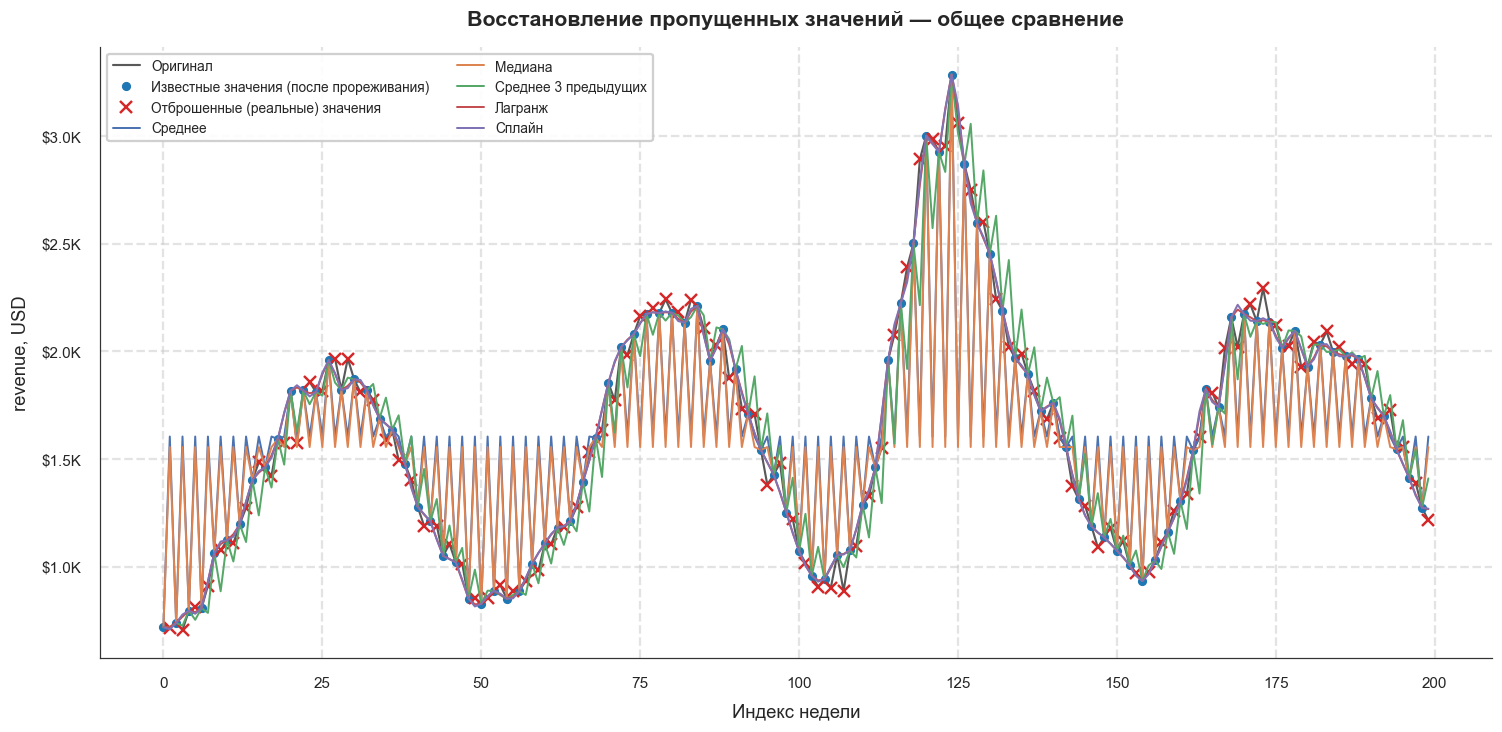

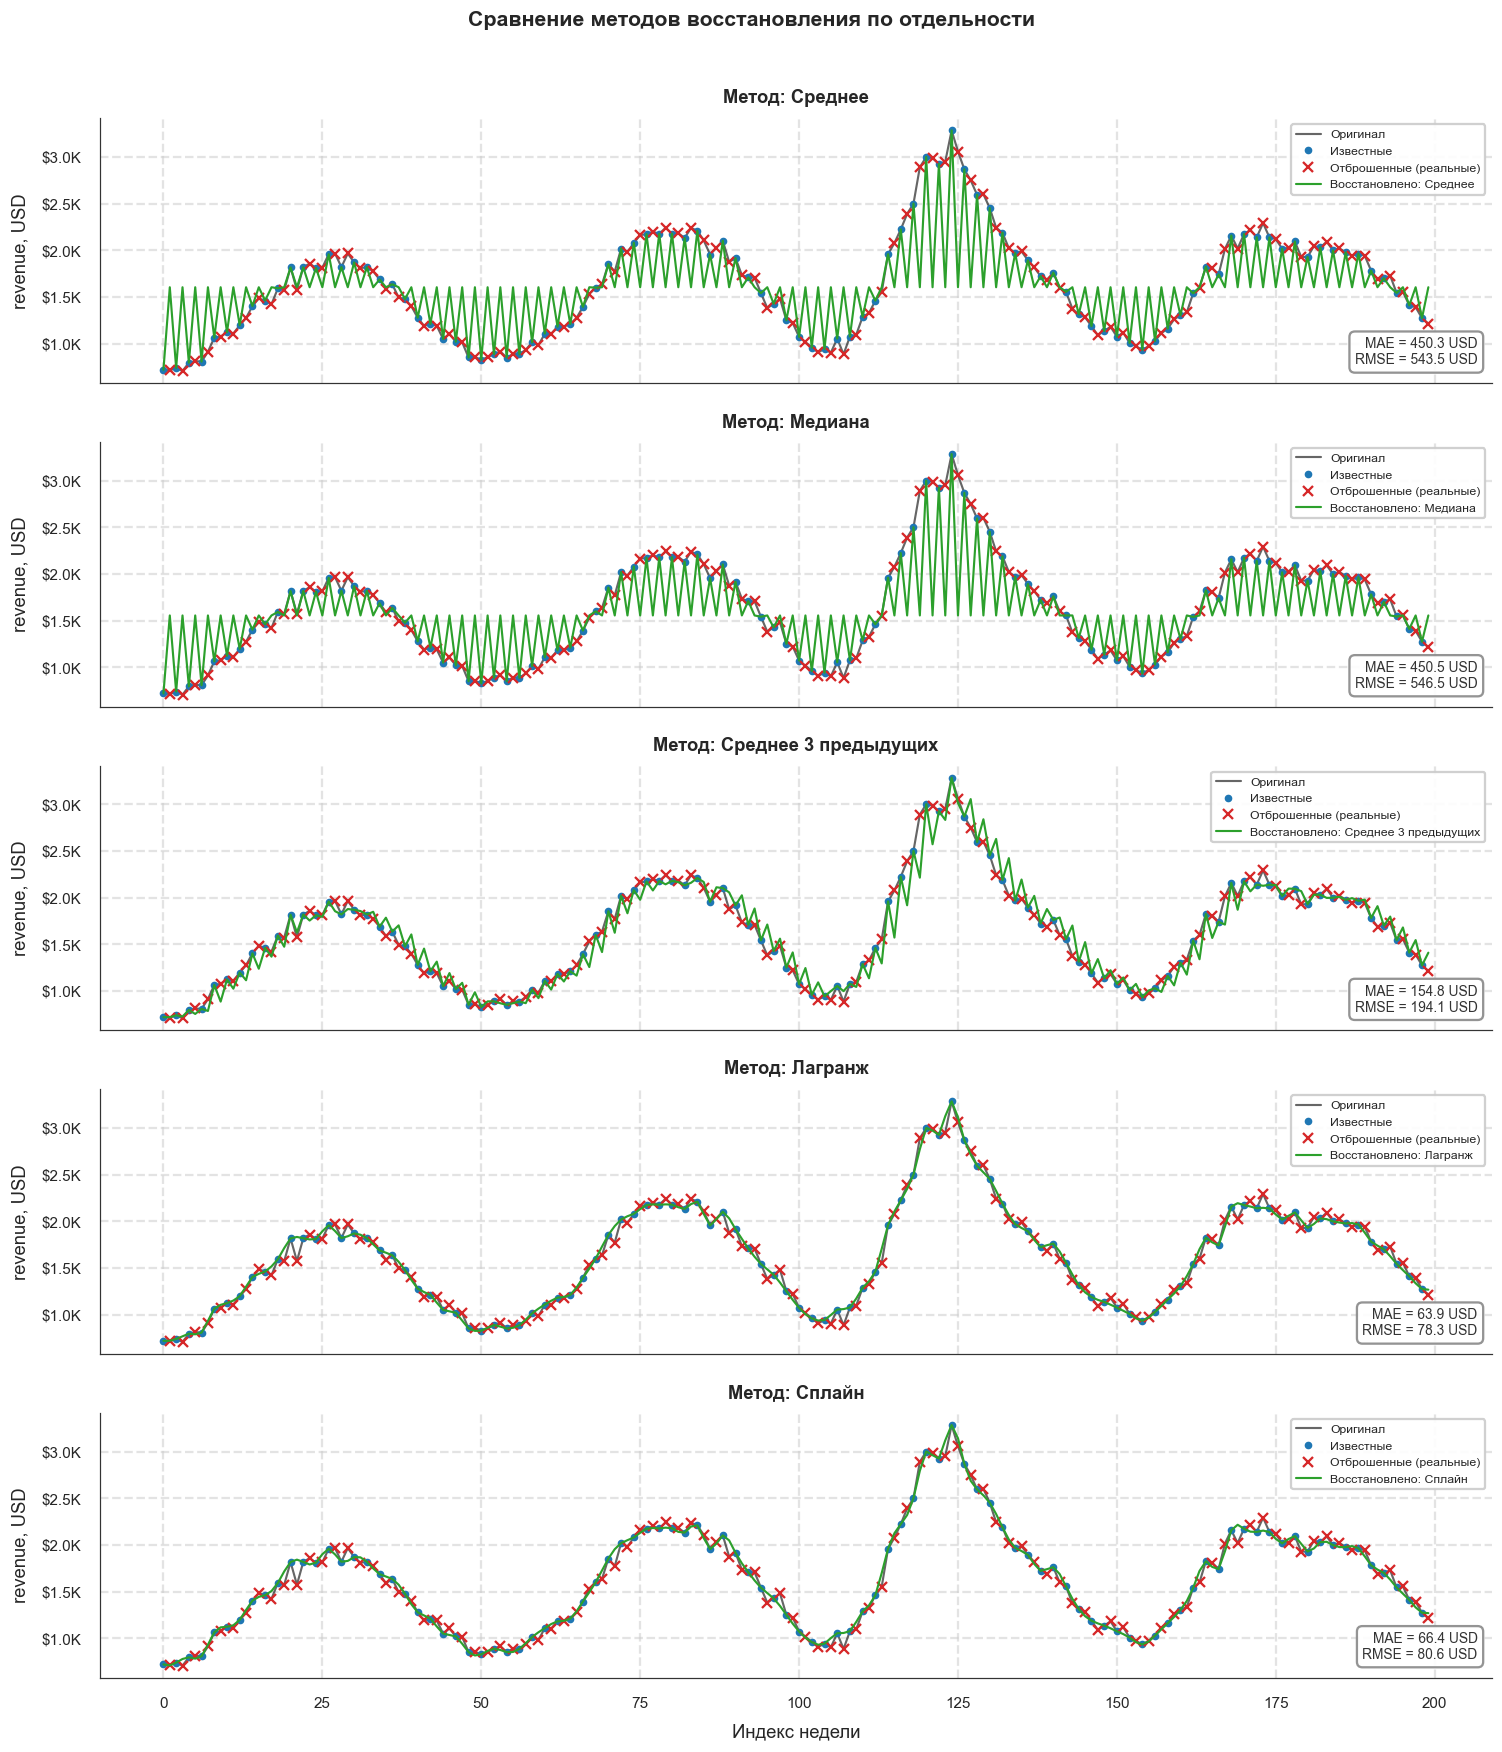


Сводная таблица ошибок по отброшенным точкам
                      MAE, USD  RMSE, USD  Max |ошибка|, USD
Метод                                                       
Среднее                 449.58     524.98            1454.42
Медиана                 448.72     527.41            1503.17
Среднее 3 предыдущих    154.61     188.32             676.44
Лагранж                  63.07      79.60             258.45
Сплайн                   65.92      82.50             268.87


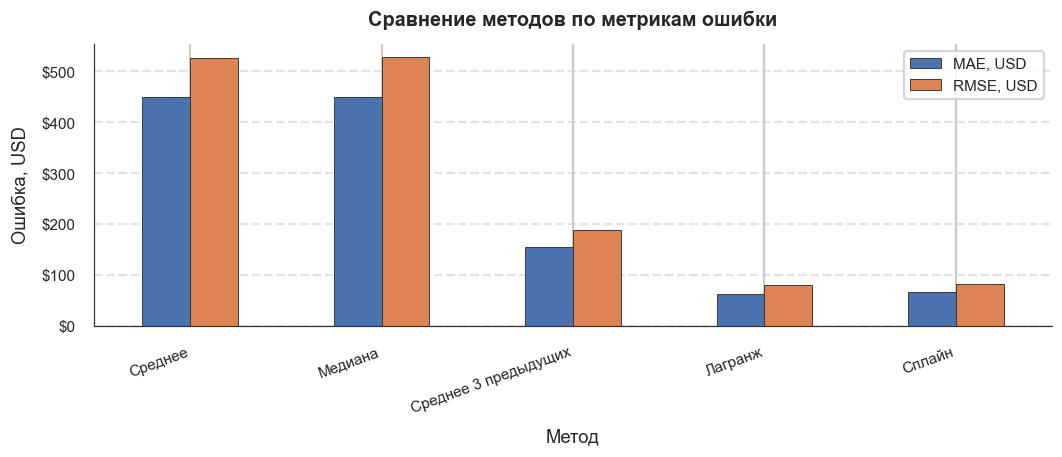

In [31]:



def _apply_dollar_axis(ax):
    from matplotlib.ticker import FuncFormatter
    ax.yaxis.set_major_formatter(FuncFormatter(_dollar_formatter))


def stage6_plot(original, thinned, filled_dict, n_show=200,
                value_name='revenue', index_name='Неделя'):
    if n_show is None or n_show > len(original):
        n_show = len(original)

    idx = slice(0, n_show)
    x = original.index[idx]
    y_true = original.to_numpy()[idx]
    y_known = thinned.to_numpy()[idx]
    removed_mask = thinned.isna().to_numpy()[idx]

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(x, y_true, color='black', linewidth=1.4, alpha=0.65,
            label='Оригинал')
    ax.plot(x, y_known, 'o', color='tab:blue', markersize=5,
            label='Известные значения (после прореживания)')
    ax.plot(x[removed_mask], y_true[removed_mask], 'x',
            color='tab:red', markersize=8, markeredgewidth=1.6,
            label='Отброшенные (реальные) значения')

    for name, filled in filled_dict.items():
        ax.plot(x, filled.to_numpy()[idx], linewidth=1.3, label=name)

    ax.set_xlabel(index_name, labelpad=8)
    ax.set_ylabel(f'{value_name}, USD', labelpad=8)
    ax.set_title('Восстановление пропущенных значений — общее сравнение',
                 pad=14, fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)
    _apply_dollar_axis(ax)
    ax.legend(loc='upper left', fontsize=9, framealpha=0.92, ncol=2)
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()

    methods = list(filled_dict.items())
    n = len(methods)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (name, filled) in zip(axes, methods):
        y_pred = filled.to_numpy()[idx]

        err = y_true[removed_mask] - y_pred[removed_mask]
        mae = np.mean(np.abs(err)) if len(err) else 0.0
        rmse = np.sqrt(np.mean(err ** 2)) if len(err) else 0.0

        ax.plot(x, y_true, color='black', linewidth=1.4, alpha=0.6,
                label='Оригинал')
        ax.plot(x, y_known, 'o', color='tab:blue', markersize=4,
                label='Известные')
        ax.plot(x[removed_mask], y_true[removed_mask], 'x',
                color='tab:red', markersize=7, markeredgewidth=1.5,
                label='Отброшенные (реальные)')
        ax.plot(x, y_pred, color='tab:green', linewidth=1.4,
                label=f'Восстановлено: {name}')

        ax.set_ylabel(f'{value_name}, USD', labelpad=8)
        ax.set_title(f'Метод: {name}', pad=10, fontsize=12,
                     fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.55)
        ax.set_axisbelow(True)
        _apply_dollar_axis(ax)

        # плашка с метриками ошибки
        ax.text(0.99, 0.06,
                f'MAE = {mae:,.1f} USD\nRMSE = {rmse:,.1f} USD',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=9, color='#333333',
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='white', ec='#888888', alpha=0.9))

        ax.legend(loc='upper right', fontsize=8, framealpha=0.92)

    axes[-1].set_xlabel(index_name, labelpad=8)
    sns.despine(ax=axes[-1], top=True, right=True)
    for ax in axes[:-1]:
        sns.despine(ax=ax, top=True, right=True)

    fig.suptitle('Сравнение методов восстановления по отдельности',
                 y=1.00, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    summary_rows = []
    for name, filled in filled_dict.items():
        y_pred = filled.to_numpy()
        err = original.to_numpy()[removed_mask_full := thinned.isna().to_numpy()] - \
              y_pred[removed_mask_full]
        summary_rows.append({
            'Метод': name,
            'MAE, USD': float(np.mean(np.abs(err))),
            'RMSE, USD': float(np.sqrt(np.mean(err ** 2))),
            'Max |ошибка|, USD': float(np.max(np.abs(err))),
        })
    summary = pd.DataFrame(summary_rows).set_index('Метод').round(2)
    print('\nСводная таблица ошибок по отброшенным точкам')
    print(summary.to_string())

    fig, ax = plt.subplots(figsize=(10, 4.5))
    summary[['MAE, USD', 'RMSE, USD']].plot(kind='bar', ax=ax,
                                            color=['#4c72b0', '#dd8452'],
                                            edgecolor='#333333', linewidth=0.6)
    ax.set_ylabel('Ошибка, USD', labelpad=8)
    ax.set_xlabel('Метод', labelpad=8)
    ax.set_title('Сравнение методов по метрикам ошибки',
                 pad=12, fontsize=13, fontweight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)
    plt.xticks(rotation=20, ha='right')
    _apply_dollar_axis(ax)
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()

def stage1_thin(series, mode='every_second', start_idx=None,
                length=6, step=2, offset=1):
    s = series.copy().astype(float)
    n = len(s)

    if mode == 'block':
        if start_idx is None:
            start_idx = max(0, n // 2 - length // 2)
        end_idx = min(n, start_idx + length)
        removed_idx = np.arange(start_idx, end_idx)

    elif mode == 'every_second':
        removed_idx = np.arange(offset, n, step)

    else:
        raise ValueError(f'Неизвестный режим прореживания: {mode}')

    s.iloc[removed_idx] = np.nan

    print(f'Схема пропусков: "{mode}"')
    if mode == 'block':
        print(f'  Длительность: {len(removed_idx)} недель подряд')
    else:
        print(f'  Каждый {step}-й элемент, начиная с позиции {offset}')
        print(f'  Всего отброшено: {len(removed_idx)} значений')
    print(f'  Длина агрегированного ряда: {n}')
    print(f'  Известных точек: {s.notna().sum()}')
    print(f'  Пропусков:      {s.isna().sum()}')
    return s


def stage2_mean_median(thinned):
    s = thinned.copy().astype(float)
    mean_val = s.mean()
    median_val = s.median()

    filled_mean = s.fillna(mean_val)
    filled_median = s.fillna(median_val)

    print('Заполнение средним/медианой')
    print(f'  Среднее: {mean_val:.4f}')
    print(f'  Медиана: {median_val:.4f}')
    print(f'  NaN в mean:   {filled_mean.isna().sum()}')
    print(f'  NaN в median: {filled_median.isna().sum()}')
    return filled_mean, filled_median


def stage3_previous_3_mean(thinned):
    s = thinned.copy().astype(float)

    for i in range(len(s)):
        if pd.isna(s.iloc[i]):
            prev = s.iloc[max(0, i - 3):i].dropna()
            if len(prev) > 0:
                s.iloc[i] = prev.mean()
            else:
                next_vals = s.iloc[i + 1:].dropna()
                if len(next_vals) > 0:
                    s.iloc[i] = next_vals.iloc[0]
                else:
                    s.iloc[i] = s.mean()

    s = s.ffill().bfill()

    print('Заполнение средним 3-х предыдущих')
    print(f'  NaN осталось: {s.isna().sum()}')
    return s


def stage4_lagrange(thinned, window=4):
    s = thinned.copy().astype(float)
    x = np.arange(len(s))
    known_mask = s.notna().values
    known_x = x[known_mask]
    known_y = s[known_mask].values

    if len(known_x) < window:
        return s.interpolate(method='linear').ffill().bfill()

    for i in range(len(s)):
        if pd.isna(s.iloc[i]):
            pos = np.searchsorted(known_x, i)
            half = window // 2
            start = max(0, pos - half)
            end = min(len(known_x), start + window)
            start = max(0, end - window)

            xs = known_x[start:end]
            ys = known_y[start:end]

            if len(xs) >= 2:
                poly = lagrange(xs, ys)
                s.iloc[i] = poly(i)

    s = s.ffill().bfill()

    print('Лагранж (окно=4)')
    print(f'  NaN осталось: {s.isna().sum()}')
    print(f'  min/max: {s.min():.4f} / {s.max():.4f}')
    return s


def stage5_cubic_spline(thinned):
    s = thinned.copy().astype(float)
    x = np.arange(len(s))
    known_mask = s.notna().values

    if known_mask.sum() < 4:
        return s.interpolate(method='linear').ffill().bfill()

    cs = CubicSpline(x[known_mask], s[known_mask].values)
    s.iloc[:] = cs(x)

    print('Кубический сплайн')
    print(f'  NaN осталось: {s.isna().sum()}')
    print(f'  min/max: {s.min():.4f} / {s.max():.4f}')
    return s

if datetime_col and value_col:
    series = (df.groupby(datetime_col)[value_col].mean()
                .reset_index()[value_col].astype(float))
elif value_col:
    series = df[value_col].astype(float)
else:
    series = None

series = series.head(1000).reset_index(drop=True)
thinned = stage1_thin(series)
filled_mean, filled_median = stage2_mean_median(thinned)
filled_prev3 = stage3_previous_3_mean(thinned)
filled_lagrange = stage4_lagrange(thinned)
filled_spline = stage5_cubic_spline(thinned)

filled_dict = {
    'Среднее': filled_mean,
    'Медиана': filled_median,
    'Среднее 3 предыдущих': filled_prev3,
    'Лагранж': filled_lagrange,
    'Сплайн': filled_spline,
}

stage6_plot(series, thinned, filled_dict, n_show=200,
            value_name=value_col if value_col else 'value',
            index_name='Индекс недели')


=== Правило 2/3 сигма для "Среднее 3 предыдущих" ===
  Среднее: -0.4903
  Стд. отклонение: 188.9267
  [2σ] границы: [-378.34; 377.36]
        выбросов: 6 (3.85% от 156)
  [3σ] границы: [-567.27; 566.29]
        выбросов: 1 (0.64% от 156)


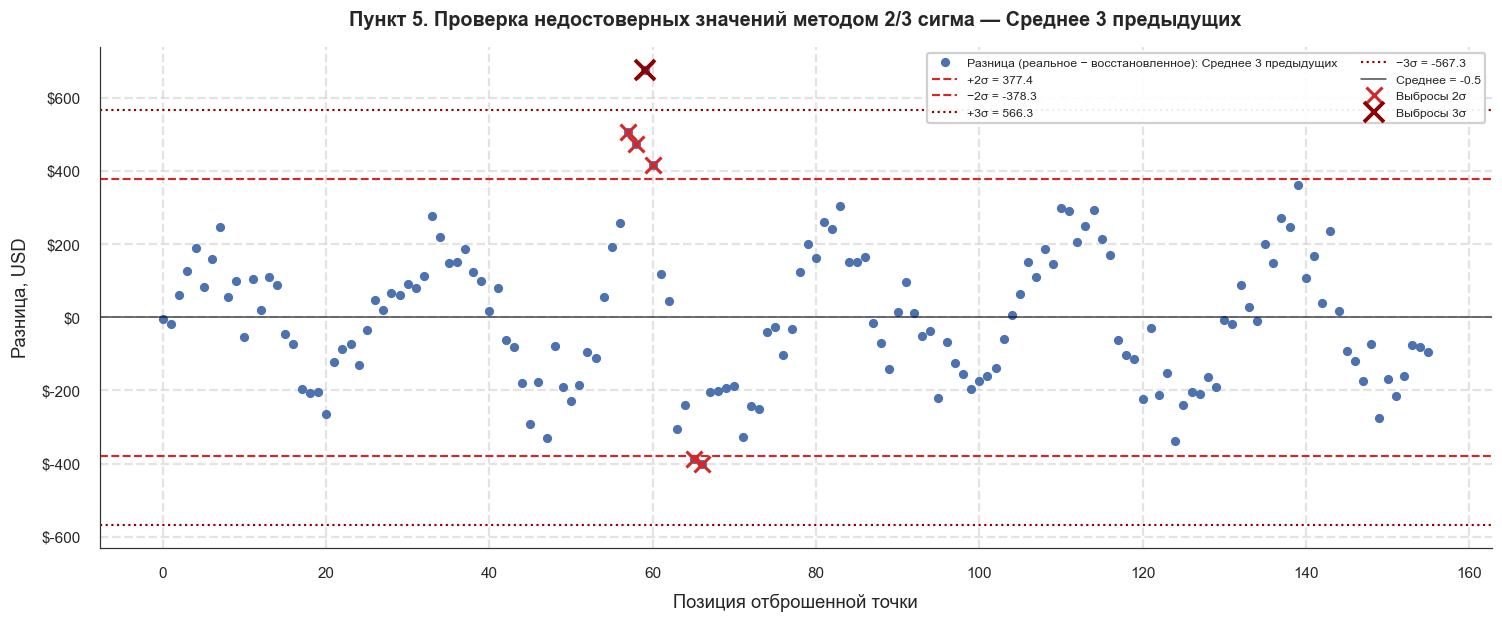

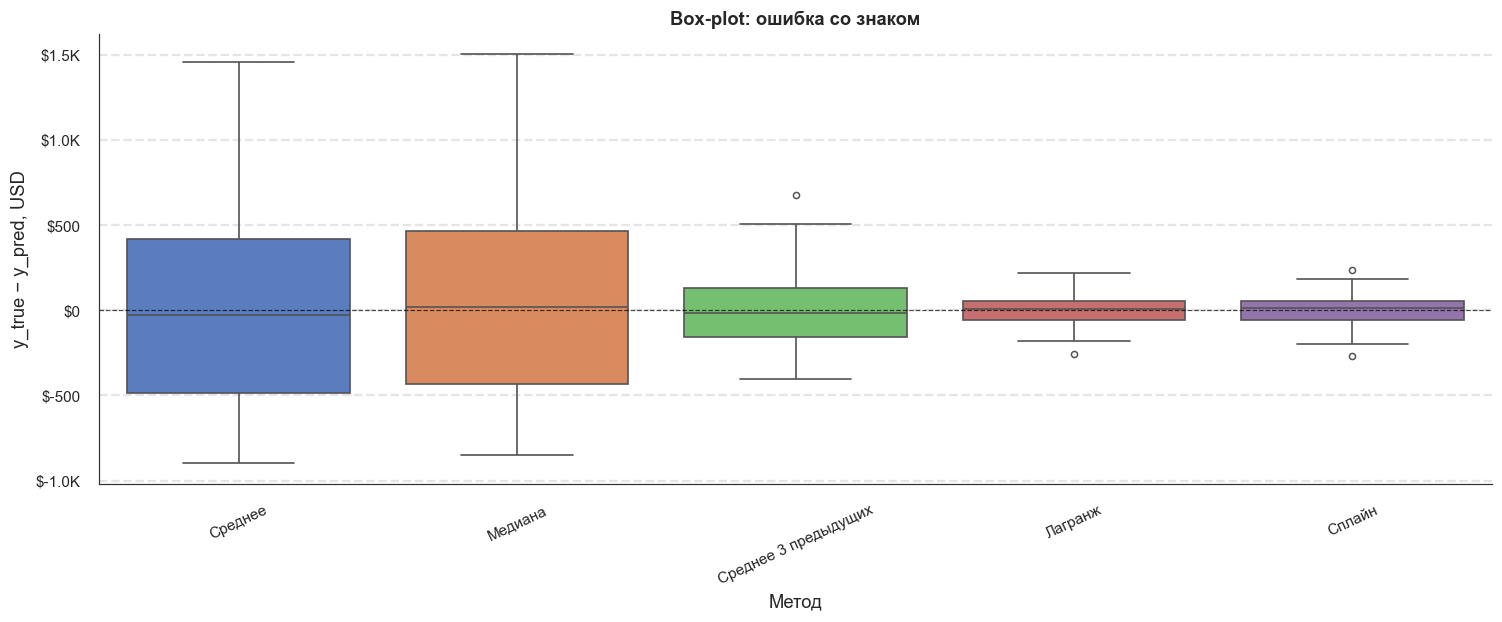


=== Сводка выбросов по методу 2/3 сигма ===
                      Среднее, USD  Стд, USD  Выбросов 2σ  Выбросов 3σ  Доля 2σ, %  Доля 3σ, %
Метод                                                                                         
Среднее                       1.80    526.67            5            0        3.21        0.00
Медиана                      50.56    526.67            5            0        3.21        0.00
Среднее 3 предыдущих         -0.49    188.93            6            1        3.85        0.64
Лагранж                      -2.83     79.80            9            1        5.77        0.64
Сплайн                       -2.81     82.72           11            1        7.05        0.64


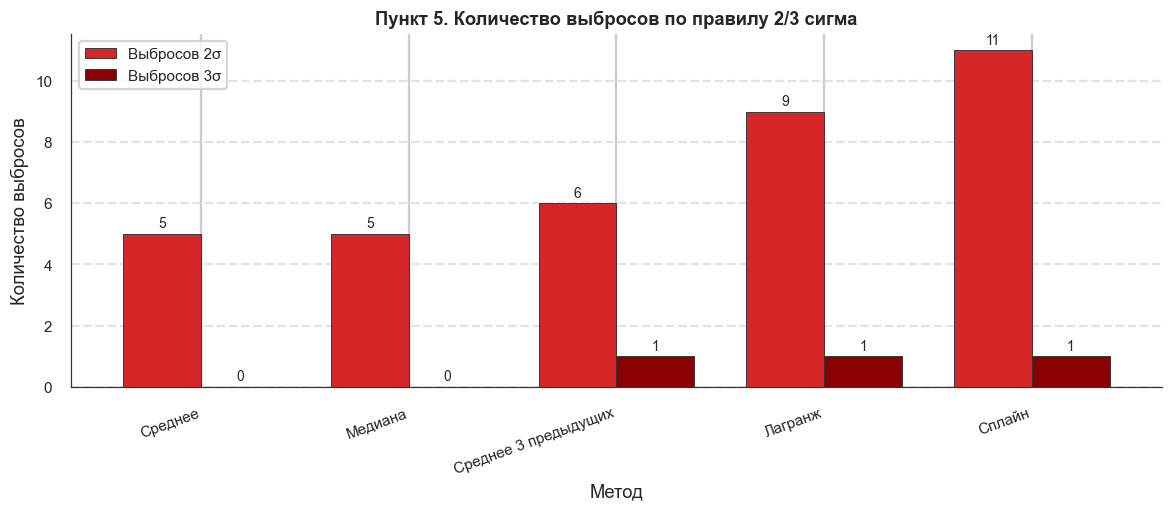


=== Текстовый вывод по пункту 5 ===
Основной метод для анализа: Среднее 3 предыдущих
  MAE  = 154.61 USD
  RMSE = 188.32 USD
  Недостоверных значений (|diff| > 2σ): 6 (3.85%)
  Недостоверных значений (|diff| > 3σ): 1 (0.64%)
  Границы 2σ: [-378.34; 377.36] USD
  Границы 3σ: [-567.27; 566.29] USD


In [32]:

def compute_errors(original, thinned, filled, method_name):
    removed_mask = thinned.isna().to_numpy()
    y_true = original.to_numpy()[removed_mask]
    y_pred = filled.to_numpy()[removed_mask]
    diff = y_true - y_pred
    signed = pd.Series(diff, name=f'{method_name}')
    absolute = pd.Series(np.abs(diff), name=f'|{method_name}|')
    return signed, absolute, y_true, y_pred


def detect_outliers_2_3_sigma(series, name='diff'):
    s = series.dropna()
    mean = s.mean()
    std = s.std()
    result = {}
    for k in (2, 3):
        lower = mean - k * std
        upper = mean + k * std
        mask = (s < lower) | (s > upper)
        result[f'{k}σ'] = {
            'lower': lower,
            'upper': upper,
            'count': int(mask.sum()),
            'share': float(mask.mean()),
            'values': s[mask],
        }
    print(f'=== Правило 2/3 сигма для "{name}" ===')
    print(f'  Среднее: {mean:,.4f}')
    print(f'  Стд. отклонение: {std:,.4f}')
    for key, info in result.items():
        print(f'  [{key}] границы: [{info["lower"]:,.2f}; {info["upper"]:,.2f}]')
        print(f'        выбросов: {info["count"]} '
              f'({info["share"]*100:.2f}% от {len(s)})')
    return result


def plot_sigma_outliers(signed_diff, sigma_info, name='diff'):
    s = signed_diff.dropna()
    mean = s.mean()
    std = s.std()

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(s))
    ax.plot(x, s.to_numpy(), 'o', color='#4c72b0', markersize=5,
            label=f'Разница (реальное − восстановленное): {name}')

    for k, color, style in [(2, '#d62728', '--'), (3, '#8b0000', ':')]:
        ax.axhline(mean + k * std, color=color, linestyle=style,
                   linewidth=1.4, label=f'+{k}σ = {mean + k*std:,.1f}')
        ax.axhline(mean - k * std, color=color, linestyle=style,
                   linewidth=1.4, label=f'−{k}σ = {mean - k*std:,.1f}')

    ax.axhline(mean, color='black', linewidth=1.0, alpha=0.7,
               label=f'Среднее = {mean:,.1f}')

    out2 = sigma_info['2σ']['values']
    if len(out2) > 0:
        idx2 = [s.index.get_loc(i) for i in out2.index]
        ax.plot(idx2, out2.to_numpy(), 'x', color='#d62728',
                markersize=10, markeredgewidth=2, label='Выбросы 2σ')

    out3 = sigma_info['3σ']['values']
    if len(out3) > 0:
        idx3 = [s.index.get_loc(i) for i in out3.index]
        ax.plot(idx3, out3.to_numpy(), 'x', color='#8b0000',
                markersize=13, markeredgewidth=2.5, label='Выбросы 3σ')

    ax.set_xlabel('Позиция отброшенной точки', labelpad=8)
    ax.set_ylabel(f'Разница, USD', labelpad=8)
    ax.set_title(f'Пункт 5. Проверка недостоверных значений методом 2/3 сигма — {name}',
                 pad=14, fontsize=13, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)
    _apply_dollar_axis(ax)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.92, ncol=2)
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()


def plot_error_box_violin(errors_signed, errors_abs):
    fig, axes = plt.subplots(1, 1, figsize=(14, 6))

    methods = list(errors_signed.keys())
    signed_df = pd.DataFrame({m: errors_signed[m].to_numpy() for m in methods})
    abs_df = pd.DataFrame({m: errors_abs[m].to_numpy() for m in methods})

    palette = sns.color_palette('muted', n_colors=len(methods))

    sns.boxplot(data=signed_df, ax=axes, palette=palette,
                linewidth=1.1, fliersize=4)
    axes.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    axes.set_title('Box-plot: ошибка со знаком', fontsize=12, fontweight='bold')
    axes.set_ylabel('y_true − y_pred, USD')
    axes.set_xlabel('Метод')
    axes.tick_params(axis='x', rotation=25)
    axes.grid(True, axis='y', linestyle='--', alpha=0.5)
    axes.set_axisbelow(True)
    _apply_dollar_axis(axes)
    sns.despine(ax=axes, top=True, right=True)

    
    plt.tight_layout()
    plt.show()


def outliers_summary_table(errors_signed):
    rows = []
    for name, s in errors_signed.items():
        s_clean = s.dropna()
        mean = s_clean.mean()
        std = s_clean.std()
        n2 = int(((s_clean < mean - 2 * std) | (s_clean > mean + 2 * std)).sum())
        n3 = int(((s_clean < mean - 3 * std) | (s_clean > mean + 3 * std)).sum())
        rows.append({
            'Метод': name,
            'Среднее, USD': mean,
            'Стд, USD': std,
            'Выбросов 2σ': n2,
            'Выбросов 3σ': n3,
            'Доля 2σ, %': 100 * n2 / len(s_clean),
            'Доля 3σ, %': 100 * n3 / len(s_clean),
        })
    df_sum = pd.DataFrame(rows).set_index('Метод').round(2)
    print('\n=== Сводка выбросов по методу 2/3 сигма ===')
    print(df_sum.to_string())

    fig, ax = plt.subplots(figsize=(11, 5))
    df_sum[['Выбросов 2σ', 'Выбросов 3σ']].plot(
        kind='bar', ax=ax,
        color=['#d62728', '#8b0000'],
        edgecolor='#333333', linewidth=0.6, width=0.75)
    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=2)
    ax.set_ylabel('Количество выбросов')
    ax.set_xlabel('Метод')
    ax.set_title('Пункт 5. Количество выбросов по правилу 2/3 сигма',
                 fontsize=12, fontweight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)
    plt.xticks(rotation=20, ha='right')
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()

    return df_sum



if 'filled_dict' in dir() and 'thinned' in dir() and 'series' in dir():

    method_for_sigma = 'Среднее 3 предыдущих'
    if method_for_sigma not in filled_dict:
        method_for_sigma = list(filled_dict.keys())[0]

    signed, absolute, y_true, y_pred = compute_errors(
        series, thinned, filled_dict[method_for_sigma], method_for_sigma
    )

    sigma_info = detect_outliers_2_3_sigma(signed, name=method_for_sigma)
    plot_sigma_outliers(signed, sigma_info, name=method_for_sigma)

    errors_signed = {}
    errors_abs = {}
    for name, filled in filled_dict.items():
        s, a, _, _ = compute_errors(series, thinned, filled, name)
        errors_signed[name] = s
        errors_abs[name] = a

    plot_error_box_violin(errors_signed, errors_abs)
    summary_df = outliers_summary_table(errors_signed)

    print('\n=== Текстовый вывод по пункту 5 ===')
    print(f'Основной метод для анализа: {method_for_sigma}')
    print(f'  MAE  = {np.mean(np.abs(signed)):,.2f} USD')
    print(f'  RMSE = {np.sqrt(np.mean(signed**2)):,.2f} USD')
    info2 = sigma_info['2σ']
    info3 = sigma_info['3σ']
    print(f'  Недостоверных значений (|diff| > 2σ): {info2["count"]} '
          f'({info2["share"]*100:.2f}%)')
    print(f'  Недостоверных значений (|diff| > 3σ): {info3["count"]} '
          f'({info3["share"]*100:.2f}%)')
    print(f'  Границы 2σ: [{info2["lower"]:,.2f}; {info2["upper"]:,.2f}] USD')
    print(f'  Границы 3σ: [{info3["lower"]:,.2f}; {info3["upper"]:,.2f}] USD')

else:
    print('Сначала запустите ячейку с пунктом 4 — нужны series, thinned, filled_dict.')

Схема пропусков: "сбой (6 недель подряд)"
  Интервал: 2021-05-29 00:00:00 — 2021-07-10
  Длительность: 6 недель
  Затронуто строк: 8613
  Длина агрегированного ряда: 313
  Известных точек: 307
  Пропусков:      6
  Naive-MAE: 86.87 USD
Заполнение средним 3-х предыдущих
  NaN осталось: 0
Лагранж (окно=4)
  NaN осталось: 0
  min/max: 706.4657 / 3401.7255
Кубический сплайн
  NaN осталось: 0
  min/max: 706.4657 / 3474.2976

=== Метрики по искусственному пропуску ===
                           MAE      RMSE    MAPE   MASE
Метод                                                  
Среднее               1137.651  1155.027  41.502  8.089
Медиана               1167.513  1184.451  42.605  8.301
Среднее 3 предыдущих   385.037   441.274  14.791  2.738
Лагранж                280.656   328.785  10.045  1.995
Сплайн                 325.757   382.582  11.644  2.316


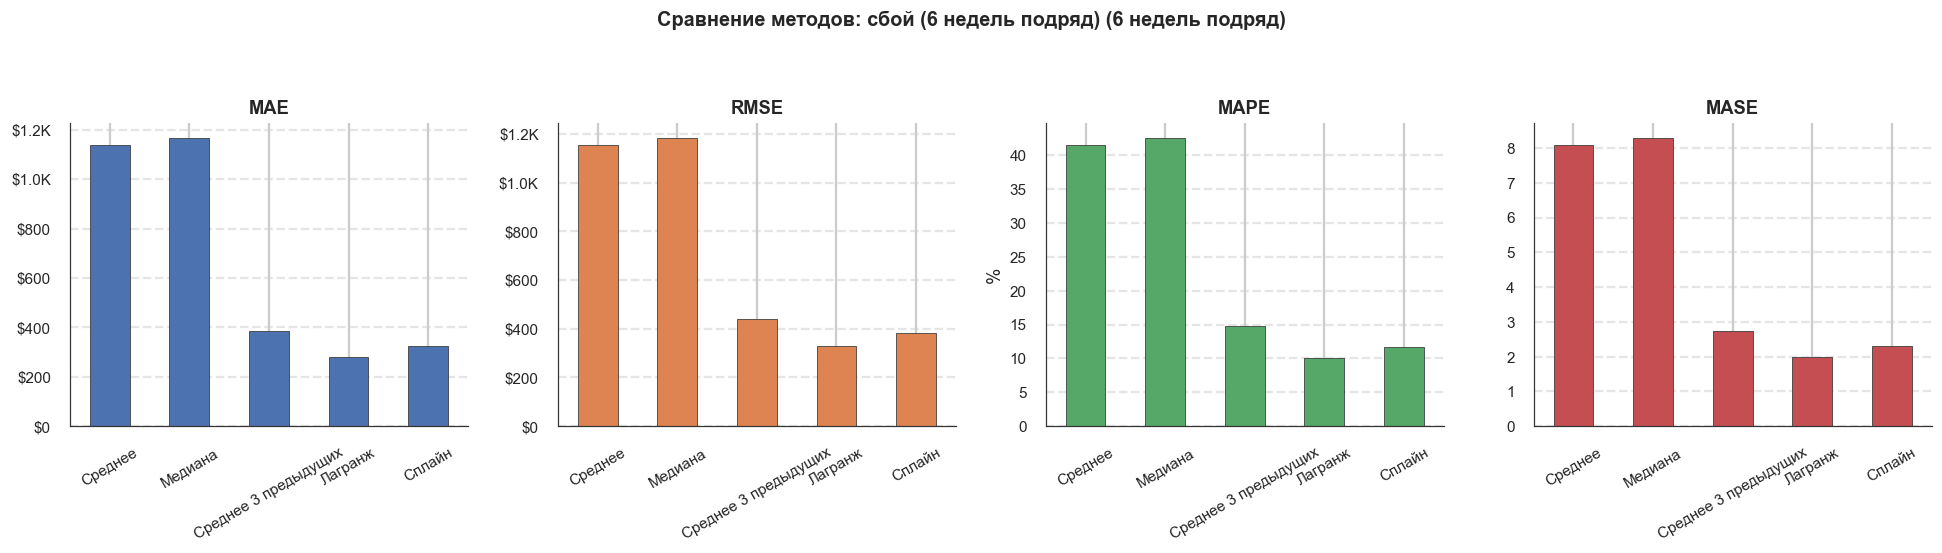

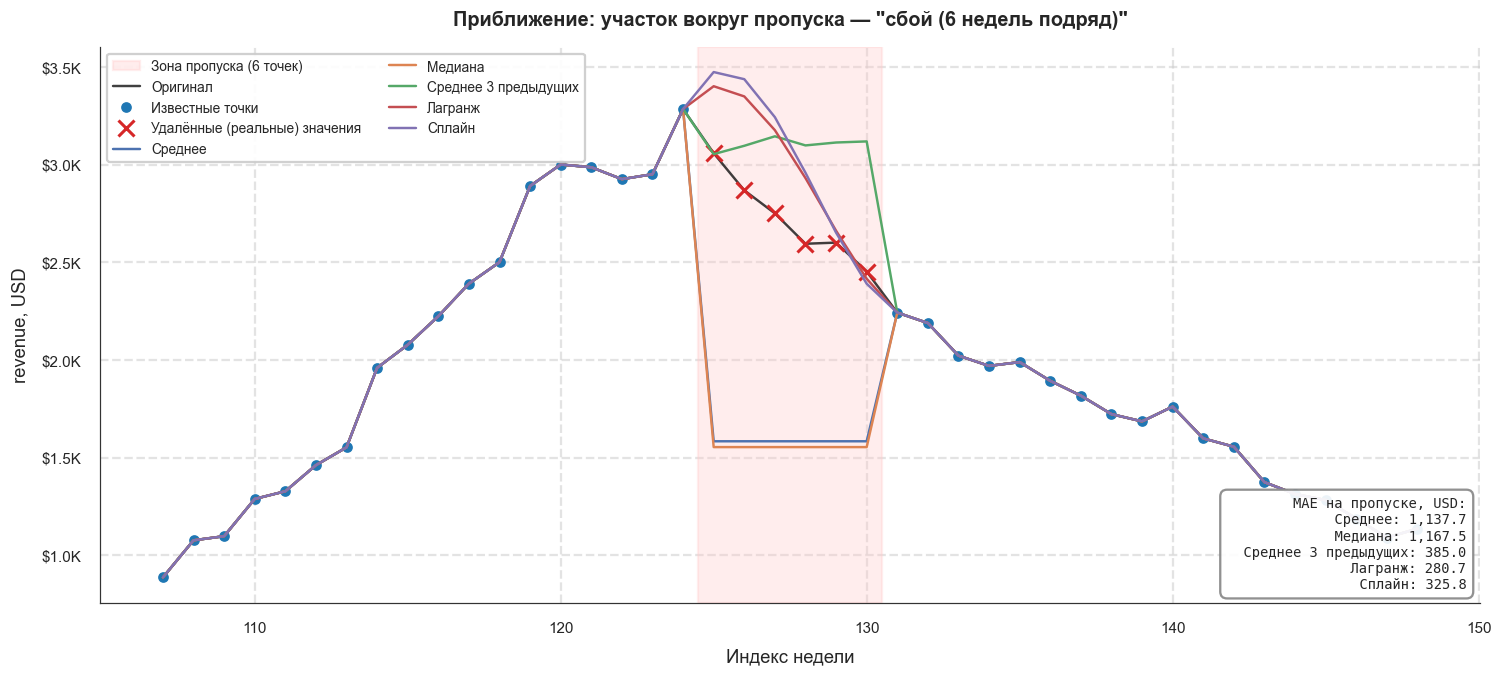


Итоговая таблица
                           MAE      RMSE    MAPE   MASE
Метод                                                  
Среднее               1137.651  1155.027  41.502  8.089
Медиана               1167.513  1184.451  42.605  8.301
Среднее 3 предыдущих   385.037   441.274  14.791  2.738
Лагранж                280.656   328.785  10.045  1.995
Сплайн                 325.757   382.582  11.644  2.316


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error



def create_failure(df, datetime_col, value_col,
                          start_date, n_weeks=6, label='сбой'):
    df2 = df.copy()
    end_date = pd.Timestamp(start_date) + pd.Timedelta(weeks=n_weeks)
    mask = (df2[datetime_col] >= pd.Timestamp(start_date)) & \
           (df2[datetime_col] < end_date)
    df2.loc[mask, value_col] = np.nan
    print(f'Схема пропусков: "{label}"')
    print(f'  Интервал: {start_date} — {end_date.date()}')
    print(f'  Длительность: {n_weeks} недель')
    print(f'  Затронуто строк: {int(mask.sum())}')
    return df2, mask


def build_weekly_from_missing(df_missing, datetime_col, value_col):
    weekly = (df_missing.groupby(datetime_col)[value_col].mean()
              .reset_index().sort_values(datetime_col)
              .reset_index(drop=True))
    return weekly


def calculate_metrics_extended(real, predicted, naive_baseline=None):
    real = np.asarray(real, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(real, predicted)
    rmse = np.sqrt(mean_squared_error(real, predicted))

    nonzero = real != 0
    if nonzero.any():
        mape = np.mean(np.abs((real[nonzero] - predicted[nonzero]) /
                              real[nonzero])) * 100
    else:
        mape = np.nan

    if naive_baseline is not None:
        nb = np.asarray(naive_baseline, dtype=float)
        naive_mae = np.mean(np.abs(real - nb))
        mase = mae / naive_mae if naive_mae > 0 else np.nan
    else:
        mase = np.nan

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'MASE': mase}


def run_imputation_experiment(df, datetime_col, value_col,
                               start_date, n_weeks=6, label='сбой датчика'):
    df_missing, mask = create_failure(df, datetime_col, value_col,
                                             start_date, n_weeks, label)

    weekly_full = build_weekly_from_missing(df, datetime_col, value_col)
    weekly_missing = build_weekly_from_missing(df_missing, datetime_col, value_col)

    series = weekly_full[value_col].astype(float).reset_index(drop=True)
    thinned = weekly_missing[value_col].astype(float).reset_index(drop=True)

    print(f'  Длина агрегированного ряда: {len(series)}')
    print(f'  Известных точек: {thinned.notna().sum()}')
    print(f'  Пропусков:      {thinned.isna().sum()}')

    known_values = series[thinned.notna()].reset_index(drop=True)
    naive_for_known = known_values.shift(1).dropna().to_numpy()
    real_for_known = known_values.iloc[1:].to_numpy()
    naive_mae_baseline = np.mean(np.abs(real_for_known - naive_for_known))
    print(f'  Naive-MAE: {naive_mae_baseline:,.2f} USD')

    filled_mean = thinned.fillna(thinned.mean())
    filled_median = thinned.fillna(thinned.median())
    filled_prev3 = stage3_previous_3_mean(thinned)
    filled_lagrange = stage4_lagrange(thinned, window=4)
    filled_spline = stage5_cubic_spline(thinned)

    methods = {
        'Среднее': filled_mean,
        'Медиана': filled_median,
        'Среднее 3 предыдущих': filled_prev3,
        'Лагранж': filled_lagrange,
        'Сплайн': filled_spline,
    }

    missing_mask = thinned.isna().to_numpy()
    y_true = series.to_numpy()[missing_mask]

    naive_per_point = series.shift(1).to_numpy()[missing_mask]

    rows = []
    for name, filled in methods.items():
        y_pred = filled.to_numpy()[missing_mask]
        metrics = calculate_metrics_extended(y_true, y_pred,
                                             naive_baseline=naive_per_point)
        metrics['Метод'] = name
        rows.append(metrics)

    results = pd.DataFrame(rows).set_index('Метод')[
        ['MAE', 'RMSE', 'MAPE', 'MASE']
    ].round(3)
    print('\n=== Метрики по искусственному пропуску ===')
    print(results.to_string())

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
    for ax, metric, color in zip(axes, ['MAE', 'RMSE', 'MAPE', 'MASE'], colors):
        results[metric].plot(kind='bar', ax=ax, color=color,
                             edgecolor='#333333', linewidth=0.5)
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)
        sns.despine(ax=ax, top=True, right=True)
        if metric in ('MAE', 'RMSE'):
            ax.yaxis.set_major_formatter(FuncFormatter(_dollar_formatter))
        if metric == 'MAPE':
            ax.set_ylabel('%')
    fig.suptitle(f'Сравнение методов: {label} ({n_weeks} недель подряд)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    idx_missing = np.where(missing_mask)[0]
    if len(idx_missing) > 0:
        first_missing = idx_missing[0]
        last_missing = idx_missing[-1]
        margin = max(15, n_weeks * 3)
        lo = max(0, first_missing - margin)
        hi = min(len(series) - 1, last_missing + margin)

        x_zoom = series.index[lo:hi + 1]
        y_orig_zoom = series.to_numpy()[lo:hi + 1]
        y_known_zoom = thinned.to_numpy()[lo:hi + 1]

        fig, ax = plt.subplots(figsize=(14, 6.5))
        ax.axvspan(first_missing - 0.5, last_missing + 0.5,
                   color='#ffcccc', alpha=0.35,
                   label=f'Зона пропуска ({len(idx_missing)} точек)')

        ax.plot(x_zoom, y_orig_zoom, color='black', linewidth=1.6, alpha=0.75,
                label='Оригинал')
        ax.plot(x_zoom, y_known_zoom, 'o', color='tab:blue', markersize=6,
                label='Известные точки')
        ax.plot(series.index[idx_missing],
                series.to_numpy()[idx_missing], 'x',
                color='tab:red', markersize=10, markeredgewidth=2,
                label='Удалённые (реальные) значения')

        for name, filled in methods.items():
            ax.plot(x_zoom, filled.to_numpy()[lo:hi + 1],
                    linewidth=1.6, label=name)

        # метрики именно на окне пропуска — плашка
        y_true_zoom = series.to_numpy()[idx_missing]
        text_lines = ['MAE на пропуске, USD:']
        for name, filled in methods.items():
            y_pred_zoom = filled.to_numpy()[idx_missing]
            mae = np.mean(np.abs(y_true_zoom - y_pred_zoom))
            text_lines.append(f'  {name}: {mae:,.1f}')

        ax.text(0.99, 0.02, '\n'.join(text_lines),
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=9, family='monospace',
                bbox=dict(boxstyle='round,pad=0.5',
                          fc='white', ec='#888888', alpha=0.92))

        ax.set_xlabel('Индекс недели', labelpad=8)
        ax.set_ylabel(f'{value_col}, USD', labelpad=8)
        ax.set_title(f'Приближение: участок вокруг пропуска — "{label}"',
                     pad=14, fontsize=13, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.55)
        ax.set_axisbelow(True)
        ax.yaxis.set_major_formatter(FuncFormatter(_dollar_formatter))
        ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.92)
        sns.despine(ax=ax, top=True, right=True)
        plt.tight_layout()
        plt.show()
    return results, methods, series, thinned


df_sorted = df.sort_values(datetime_col).reset_index(drop=True)
dt_min = df_sorted[datetime_col].min()
dt_max = df_sorted[datetime_col].max()
span = dt_max - dt_min

start_date = (dt_min + span * 0.4).normalize()

results_extra, methods_extra, series_extra, thinned_extra = \
    run_imputation_experiment(
        df_sorted, datetime_col, value_col,
        start_date=start_date, n_weeks=6,
        label='сбой (6 недель подряд)'
    )

print('\nИтоговая таблица')
print(results_extra.to_string())